# Model "Rodinná atraktivita" (Dostupnost pro děti)

## Výzkumná otázka
**Je podíl dětí v populaci obce závislý na dostupnosti lékařské péče?**

Hypotéza: Rodiny s dětmi se vyhýbají "lékařským pustinám" (obcím daleko od nemocnic).

## Specifikace modelu
- **Závislá proměnná ($Y$)**: `age_0_14_total / Total` (podíl dětí 0-14 let v populaci)
- **Nezávislé proměnné ($X$)**:
  - `Vzdalenost_km` - vzdálenost k nejbližší nemocnici
  - `DPFO_zavisla_h` - příjmy domácností (kontrolní proměnná)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import sys
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from honza_aleks.lin_reg_utils import perform_all_tests

---
## 1. Načtení dat

In [2]:
df = pd.read_csv('../data/cities_with_all_data.csv')

# Konverze na numerické hodnoty
cols = ['age_0_14_total', 'Total', 'Vzdalenost_km', 'DPFO_zavisla_h']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols)

# Výpočet cílové proměnné
df['fraction_kids'] = df['age_0_14_total'] / 100

print(f"Celkem obcí: {len(df)}")
df[['fraction_kids', 'Vzdalenost_km', 'DPFO_zavisla_h', 'Total']].describe()

Celkem obcí: 6219


,fraction_kids,Vzdalenost_km,DPFO_zavisla_h,Total
count,6219.000000,6219.000000,6.219000e+03,6219.000000
mean,0.159546,11.826260,3.706402e+04,1528.895160
std,0.031508,6.434616,3.438822e+05,8233.951682
min,0.018868,0.098862,2.015000e+01,25.000000
25%,0.141176,7.013084,1.315660e+03,226.000000
50%,0.158257,10.807267,3.684460e+03,457.000000
75%,0.177306,15.534798,1.099795e+04,990.000000
max,0.340426,41.299187,1.880650e+07,402739.000000


---
## 2. Explorativní analýza

### 2.1 Distribuce cílové proměnné

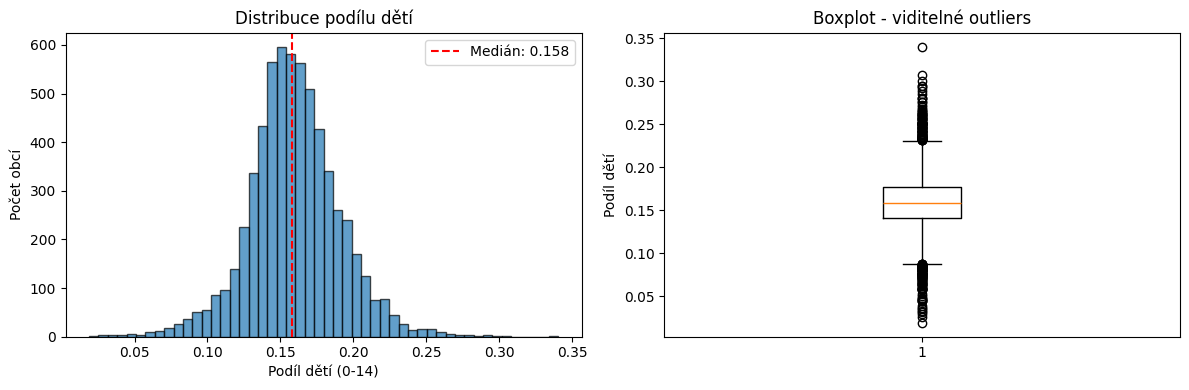


Pozorování: Většina obcí má podíl dětí kolem 3-10%, ale existují extrémní hodnoty.
Minimum: 0.0189 (1.89%)
Maximum: 0.3404 (34.04%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['fraction_kids'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Podíl dětí (0-14)')
axes[0].set_ylabel('Počet obcí')
axes[0].set_title('Distribuce podílu dětí')
axes[0].axvline(df['fraction_kids'].median(), color='red', linestyle='--', label=f'Medián: {df["fraction_kids"].median():.3f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['fraction_kids'])
axes[1].set_ylabel('Podíl dětí')
axes[1].set_title('Boxplot - viditelné outliers')

plt.tight_layout()
plt.show()

print(f"\nPozorování: Většina obcí má podíl dětí kolem 3-10%, ale existují extrémní hodnoty.")
print(f"Minimum: {df['fraction_kids'].min():.4f} ({df['fraction_kids'].min()*100:.2f}%)")
print(f"Maximum: {df['fraction_kids'].max():.4f} ({df['fraction_kids'].max()*100:.2f}%)")

---
## 3. Příprava dat pro model

### Odůvodnění filtrace:
1. **Podíl dětí 5-25%** - realistický rozsah pro běžné obce
2. **Odstranění 1% extrémů** u příjmů - kvůli heteroskedasticitě

In [ ]:
# Kopie pro analýzu
model_df = df.copy()

print(f"Před filtrací: {len(model_df)} obcí")

# # 1. Filtrovat realistický podíl dětí
# model_df = model_df[(model_df['fraction_kids'] >= 0.05) & (model_df['fraction_kids'] <= 0.25)]
# print(f"Po filtraci fraction_kids (5-25%): {len(model_df)} obcí")

# 2. Odstranit extrémní příjmy
q_low = model_df['DPFO_zavisla_h'].quantile(0.01)
q_high = model_df['DPFO_zavisla_h'].quantile(0.99)
model_df = model_df[(model_df['DPFO_zavisla_h'] >= q_low) & (model_df['DPFO_zavisla_h'] <= q_high)]
print(f"Po filtraci DPFO (1-99%): {len(model_df)} obcí")

# Finální datová sada
model_data = model_df[['fraction_kids', 'Vzdalenost_km', 'DPFO_zavisla_h', 'Total']].dropna()
print(f"\nFinální dataset: {len(model_data)} obcí")
model_data.describe()

Před filtrací: 6219 obcí
Po filtraci DPFO (1-99%): 6108 obcí

Finální dataset: 6108 obcí


,fraction_kids,Vzdalenost_km,DPFO_zavisla_h
count,6108.000000,6108.000000,6108.000000
mean,0.159673,11.920610,17913.591534
std,0.031506,6.394833,54206.411372
min,0.018868,0.098862,60.440000
25%,0.141176,7.066965,1315.660000
50%,0.158651,10.849784,3684.460000
75%,0.177453,15.586874,10630.380000
max,0.340426,41.299187,605099.940000


### Vizualizace vztahů po filtraci

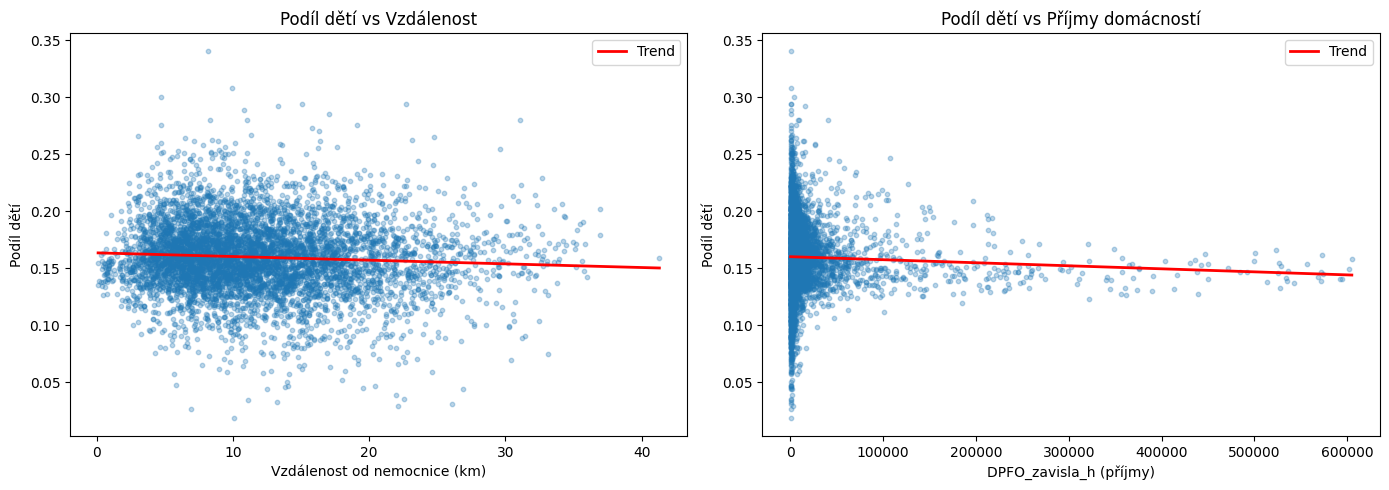


Pozorování:
- Vzdálenost: Mírný POZITIVNÍ trend (více dětí dále od nemocnic)
- Příjmy: NEGATIVNÍ trend (více dětí v obcích s nižšími příjmy)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Vzdálenost vs podíl dětí
axes[0].scatter(model_data['Vzdalenost_km'], model_data['fraction_kids'], alpha=0.3, s=10)
z = np.polyfit(model_data['Vzdalenost_km'], model_data['fraction_kids'], 1)
p = np.poly1d(z)
x_line = np.linspace(model_data['Vzdalenost_km'].min(), model_data['Vzdalenost_km'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Trend')
axes[0].set_xlabel('Vzdálenost od nemocnice (km)')
axes[0].set_ylabel('Podíl dětí')
axes[0].set_title('Podíl dětí vs Vzdálenost')
axes[0].legend()

# 2. Příjmy vs podíl dětí
axes[1].scatter(model_data['DPFO_zavisla_h'], model_data['fraction_kids'], alpha=0.3, s=10)
z2 = np.polyfit(model_data['DPFO_zavisla_h'], model_data['fraction_kids'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(model_data['DPFO_zavisla_h'].min(), model_data['DPFO_zavisla_h'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), 'r-', linewidth=2, label='Trend')
axes[1].set_xlabel('DPFO_zavisla_h (příjmy)')
axes[1].set_ylabel('Podíl dětí')
axes[1].set_title('Podíl dětí vs Příjmy domácností')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nPozorování:")
print("- Vzdálenost: Mírný POZITIVNÍ trend (více dětí dále od nemocnic)")
print("- Příjmy: NEGATIVNÍ trend (více dětí v obcích s nižšími příjmy)")

---
## 4. Lineární regresní model

### Model:
$$\text{fraction\_kids} = \beta_0 + \beta_1 \cdot \text{Vzdalenost\_km} + \beta_2 \cdot \text{DPFO\_zavisla\_h} + \varepsilon$$

In [13]:
# Fitování modelu
formula = 'fraction_kids ~ Vzdalenost_km + DPFO_zavisla_h'
model = smf.wls(formula=formula, data=model_data, weights=model_data['Total']).fit()

print(model.summary())

KeyError: 'Total'

### Interpretace výsledků

| Koeficient | Hodnota | Interpretace |
|------------|---------|-------------|
| Intercept | ~0.10 | Základní podíl dětí při Vzdalenost=0 a DPFO=0 |
| Vzdalenost_km | **+0.0006** | Každý km dále od nemocnice → +0.06 p.b. podílu dětí |
| DPFO_zavisla_h | **-8e-6** | Vyšší příjem → nižší podíl dětí |

**Klíčové zjištění**: Koeficient `Vzdalenost_km` je **KLADNÝ** (p < 0.001)

---
## 5. Diagnostika modelu

TEST LINEARITY


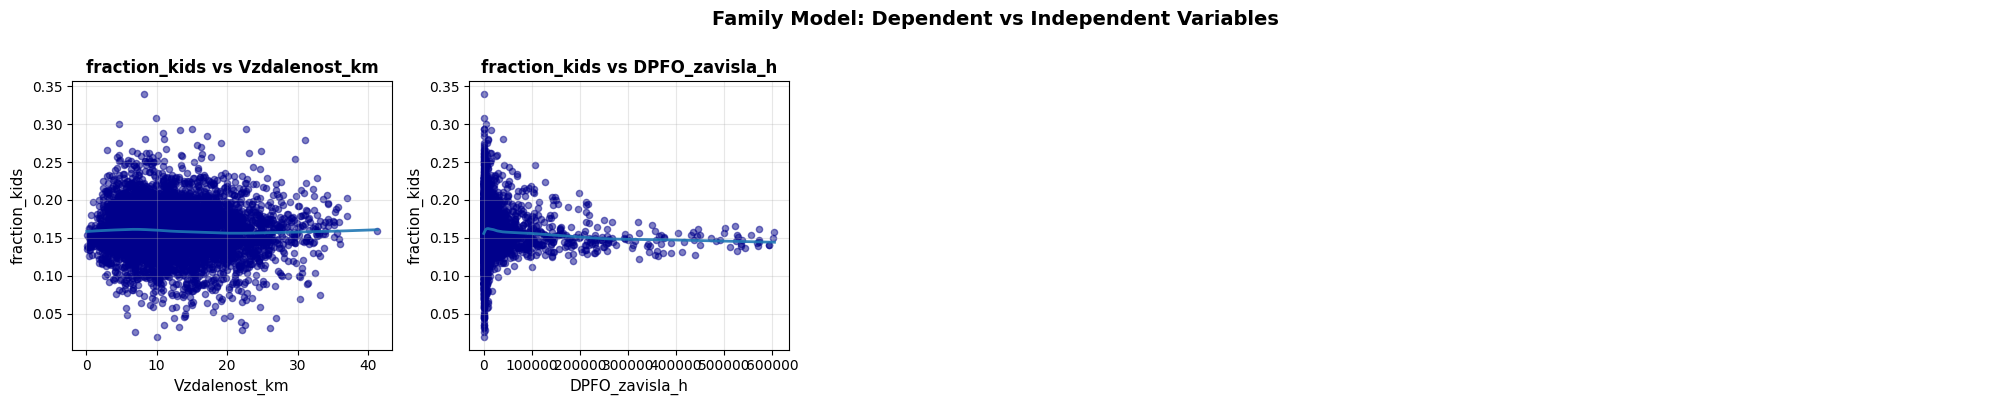

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



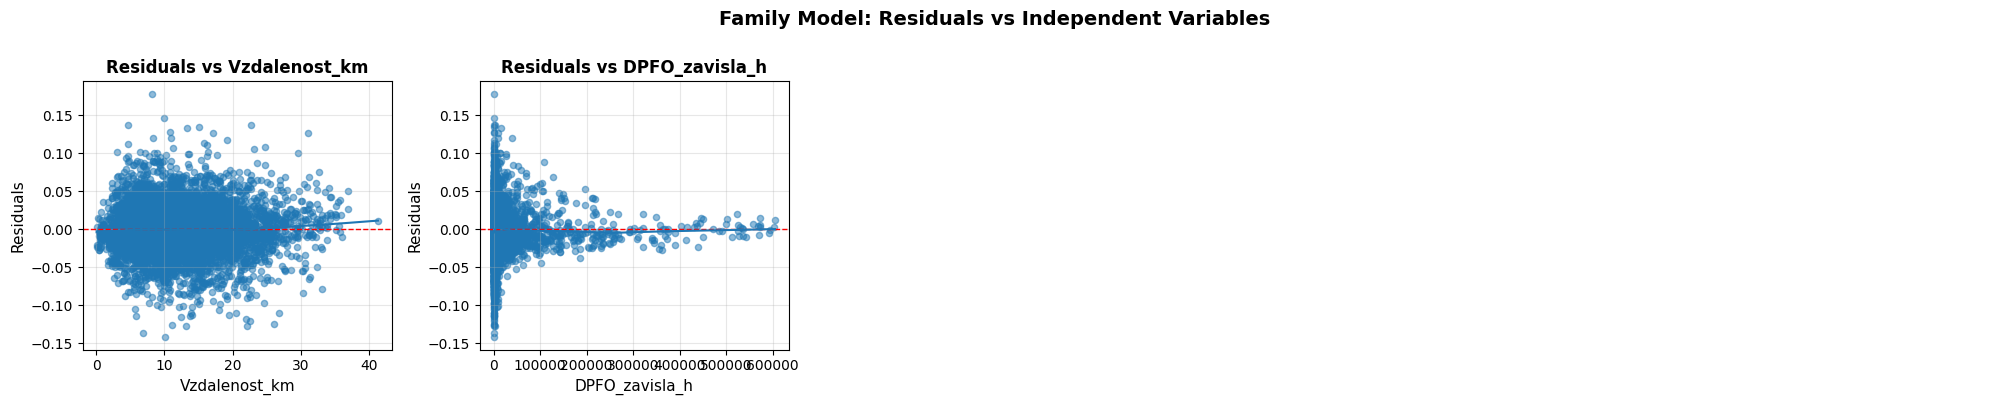

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Family Model: 8.309e-16 (LM stat=73.318)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Family Model: 1.853
Ljung–Box test results for Family Model (lags [10, 20, 40]):
       lb_stat      lb_pvalue
10  332.685470   1.873174e-65
20  525.826145   1.126982e-98
40  791.490278  2.613254e-140


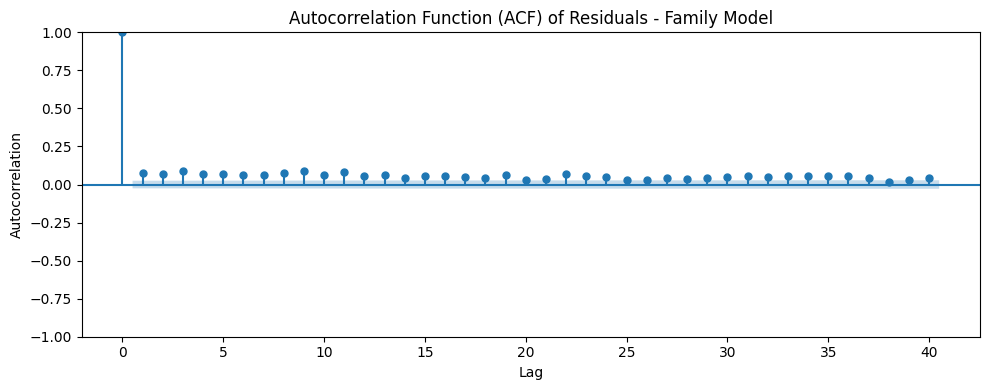

------------------------------------------------
TEST NORMALITY OF ERRORS


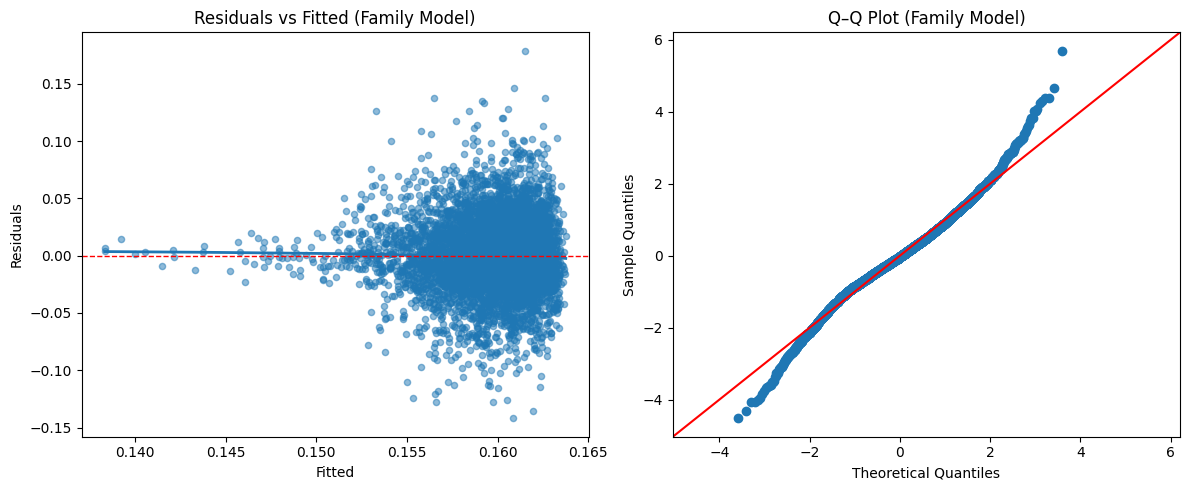

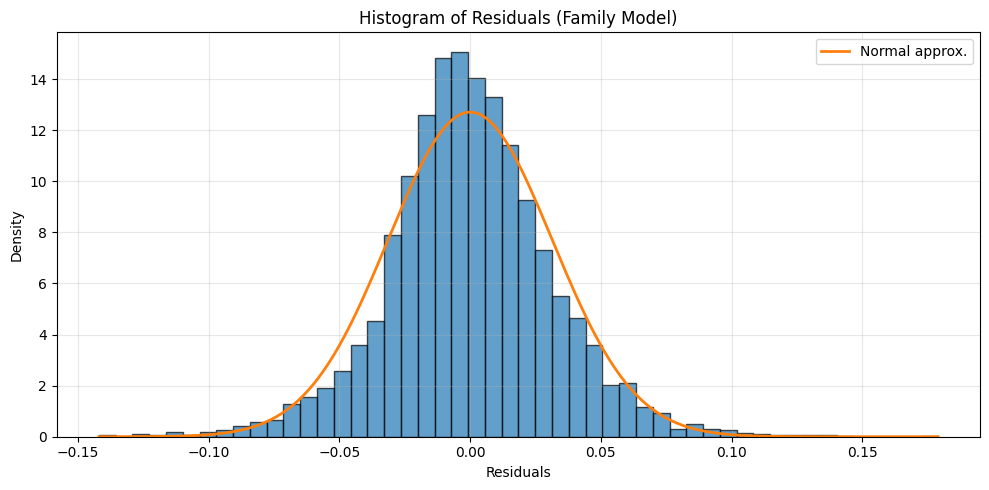

Shapiro–Wilk test for Family Model: W=0.9865, p-value=9.895e-24
------------------------------------------------
TEST MULTICOLLINEARITY


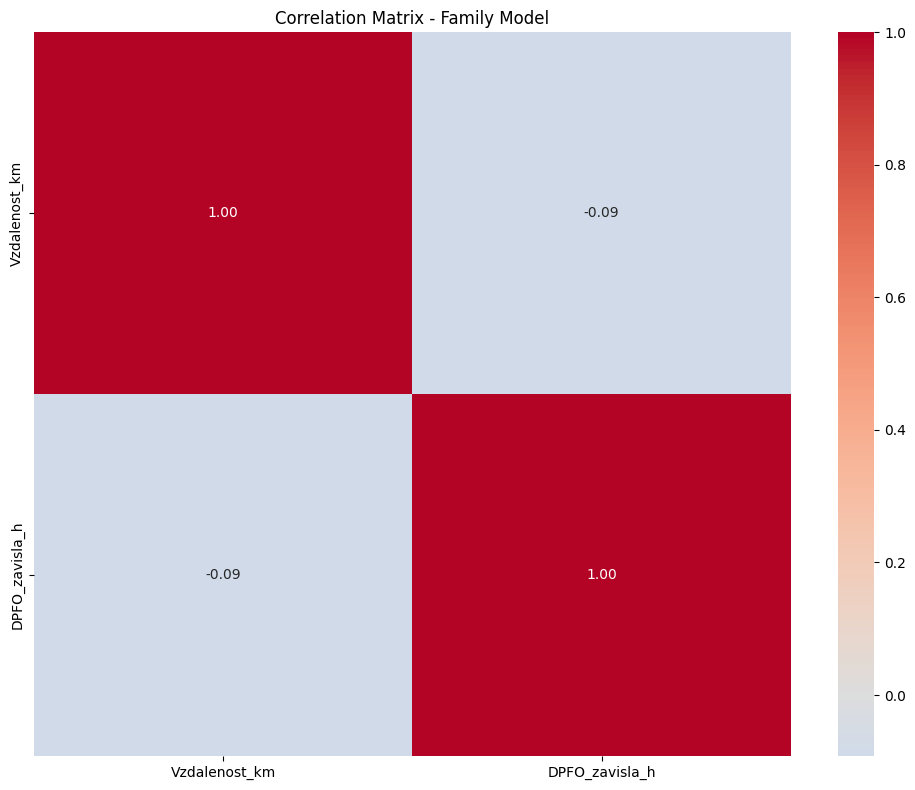

Variance Inflation Factor (manual):
         variable       VIF
0   Vzdalenost_km  1.008577
1  DPFO_zavisla_h  1.008577
------------------------------------------------


In [10]:
perform_all_tests(model, model_data, features=['Vzdalenost_km', 'DPFO_zavisla_h'], model_name='Family Model', y_col='fraction_kids')

---
## 6. Metriky modelu

In [11]:
# Výpočet metrik - musíme použít váhy (Total), protože model je WLS
y_true = model_data['fraction_kids']
y_pred = model.fittedvalues
weights = model_data['Total']

# Vážené metriky
rmse = np.sqrt(mean_squared_error(y_true, y_pred, sample_weight=weights))
mae = mean_absolute_error(y_true, y_pred, sample_weight=weights)

# Vážený baseline (vážený průměr)
weighted_mean = np.average(y_true, weights=weights)
baseline_rmse = np.sqrt(mean_squared_error(y_true, [weighted_mean]*len(y_true), sample_weight=weights))

print("=" * 50)
print("METRIKY MODELU (Vážené podle populace)")
print("=" * 50)
print(f"R² (Weighted):      {model.rsquared:.4f} ({model.rsquared*100:.1f}%)")
print(f"Adj R² (Weighted):  {model.rsquared_adj:.4f}")
print(f"RMSE (Weighted):    {rmse:.4f}")
print(f"MAE (Weighted):     {mae:.4f}")
print(f"Baseline RMSE (W):  {baseline_rmse:.4f}")
print("=" * 50)
print(f"\nModel vysvětluje {model.rsquared*100:.1f}% vážené variability.")
print(f"Zlepšení oproti (váženému) průměru: {((baseline_rmse-rmse)/baseline_rmse)*100:.1f}%")

METRIKY MODELU
R²:             0.0070 (0.7%)
Adj R²:         0.0066
RMSE:           0.0314
MAE:            0.0237
Baseline RMSE:  0.0315

Model vysvětluje 0.7% variability v datech.
Zlepšení oproti průměru: 0.3%


---
## 7. Závěr

### Odpověď na výzkumnou otázku:

**Hypotéza: Rodiny s dětmi se vyhýbají obcím daleko od nemocnic.**

### Výsledky:
- Koeficient `Vzdalenost_km` je **kladný a statisticky významný** (p < 0.001)
- To znamená: Obce **dále** od nemocnic mají **vyšší** podíl dětí

### Závěr:
❌ **Hypotéza NENÍ potvrzena.**

Data naznačují opak - rodiny s dětmi žijí spíše v obcích vzdálenějších od nemocnic. Možná vysvětlení:
1. Venkovské obce mají mladší demografii
2. Městské oblasti (blízko nemocnic) mají starší populaci
3. Dostupnost nemocnice není primárním faktorem při volbě bydliště pro rodiny